1. Imports

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random

2. Device Configuration and Seed Initialization

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Setting strict random seeds to guarantee experiment reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

3. Load CIFAR-10 Dataset

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# --- Dataset Download & Extraction ---
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# --- Data Pipeline Initialization (Dataloaders) ---
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

4. CNN Baseline Model

In [26]:
class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.sigmoid(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x

5. MLP Baseline Model

In [27]:
class InitialMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten spatial boundaries

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

6. Initialize Network

In [28]:
# --- Optimization Setup for CNN ---
model = InitialCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

7. Training Function

In [29]:
def train(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0
    gradient_norms = {}

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Monitoring gradient magnitudes across layers via param.grad attributes
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()
                if name not in gradient_norms:
                    gradient_norms[name] = []
                gradient_norms[name].append(grad_norm)

        optimizer.step()
        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Calculating layer-wise mean gradient tracking stats across the full epoch
    avg_gradients = {}
    for name in gradient_norms:
        avg_gradients[name] = np.mean(gradient_norms[name])

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, avg_gradients

8. Testing Function

In [30]:
def test(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy

9. Main Training Loop

Epoch 1/15
Training Loss: 2.1462
Training Accuracy: 18.57%
Test Accuracy: 27.08%
--------------------------------------------------
Epoch 2/15
Training Loss: 1.8762
Training Accuracy: 31.21%
Test Accuracy: 36.90%
--------------------------------------------------
Epoch 3/15
Training Loss: 1.6954
Training Accuracy: 38.42%
Test Accuracy: 40.86%
--------------------------------------------------
Epoch 4/15
Training Loss: 1.5639
Training Accuracy: 43.06%
Test Accuracy: 45.45%
--------------------------------------------------
Epoch 5/15
Training Loss: 1.4508
Training Accuracy: 47.31%
Test Accuracy: 48.74%
--------------------------------------------------
Epoch 6/15
Training Loss: 1.3739
Training Accuracy: 50.21%
Test Accuracy: 51.35%
--------------------------------------------------
Epoch 7/15
Training Loss: 1.3073
Training Accuracy: 52.46%
Test Accuracy: 52.70%
--------------------------------------------------
Epoch 8/15
Training Loss: 1.2545
Training Accuracy: 54.43%
Test Accuracy: 54

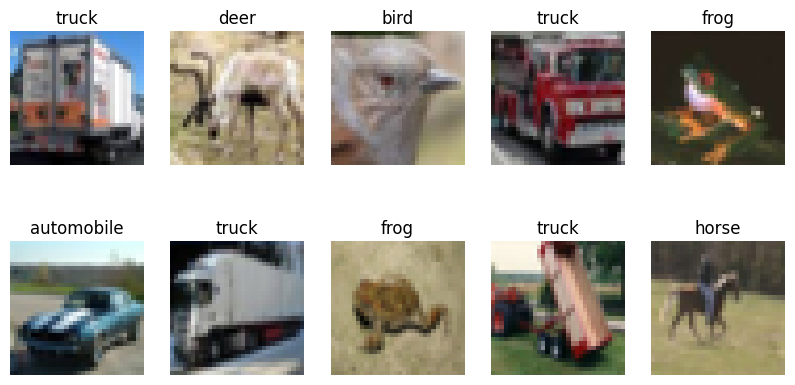

In [31]:
num_epochs = 15

train_losses, test_losses = [], []
train_accs, test_accs = [], []
all_gradients = {}

for epoch in range(num_epochs):
    train_loss, train_acc, avg_gradients = train(model, train_loader)
    test_loss, test_acc = test(model, test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Accumulating batch metrics into long-term history dictionaries
    for layer_name, grad_value in avg_gradients.items():
        if layer_name not in all_gradients:
            all_gradients[layer_name] = []
        all_gradients[layer_name].append(grad_value)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Training Accuracy: {train_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("-" * 50)

# --- Quantitative Historical Summary Breakdown ---
print("\nFINAL EVALUATION SUMMARY")
print("=" * 50)
for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}")
    print(f"Training Loss: {train_losses[epoch]:.4f}")
    print(f"Training Accuracy: {train_accs[epoch]:.2f}%")
    print(f"Test Accuracy: {test_accs[epoch]:.2f}%")
    print("-" * 50)

# --- Optimization Setup for MLP Block (Task 2 Readiness Setup) ---
mlp_model = InitialMLP().to(device)
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# --- Sample Dataset Structural Verification ---
classes = train_dataset.classes
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5  # Denormalizing pixel distributions
    img = img.permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.show()

10. QUANTITATIVE REPORT VISUALIZATIONS

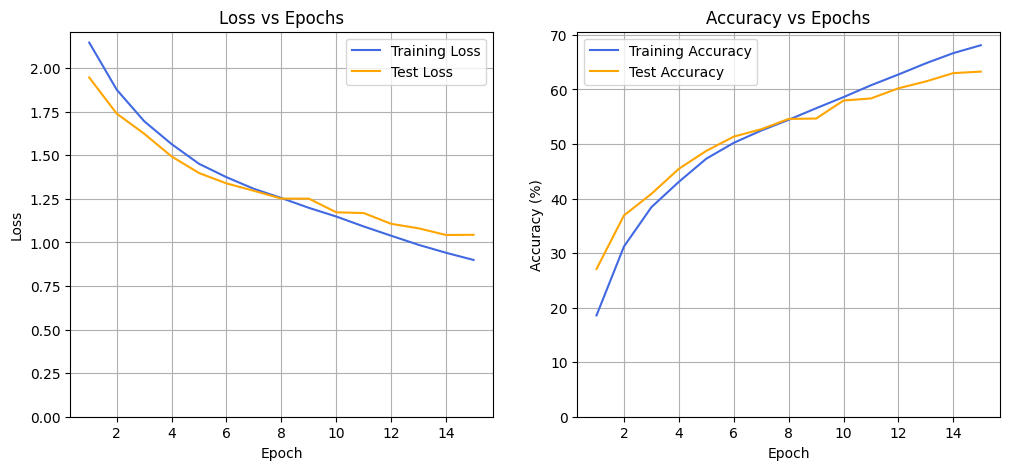

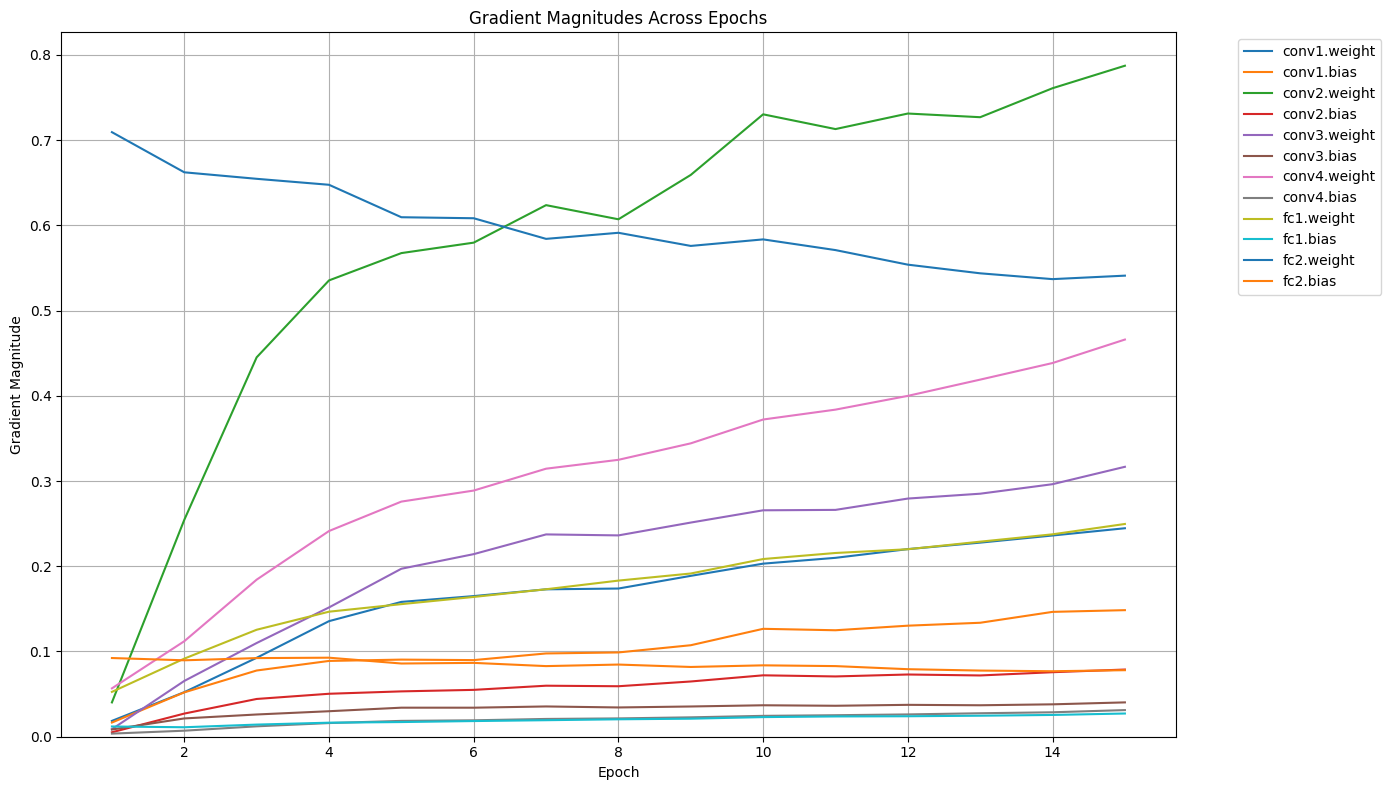

In [32]:
epochs = range(1, num_epochs + 1)

# Plot Series 1: Learning Curve Convergences (Loss & Accuracy Trajectories)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', color='royalblue')
plt.plot(epochs, test_losses, label='Test Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Training Accuracy', color='royalblue')
plt.plot(epochs, test_accs, label='Test Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epochs')
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)

plt.show()

# Plot Series 2: Backpropagation Evaluation (Layer-wise Gradient Magnitudes)
plt.figure(figsize=(14, 8))
for layer_name, gradients in all_gradients.items():
    plt.plot(epochs, gradients, label=layer_name)

plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.title('Gradient Magnitudes Across Epochs')
plt.ylim(bottom=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()